In [1]:
import numpy as np
import matplotlib.pyplot as plt

Question 3

In [2]:
def solve_LS(X: np.ndarray, b: np.ndarray) -> np.ndarray:
    """
    Solve a linear system X*sol = b.
    """
    X = np.asarray(X, dtype=float)
    b = np.asarray(b, dtype=float).reshape(-1, 1)
    sol = np.linalg.solve(X, b)
    return sol.flatten()

# Coefficient matrix for constants
X = np.array([
    [1, 1, 1],
    [1, -1, -2],
    [1, 1, 4]
])

# Initial conditions
b1 = np.array([1, 1, 1])
b2 = np.array([1, -1, 1])

# Solve for constants
C1 = solve_LS(X, b1)
C2 = solve_LS(X, b2)

print("Constants for IC set 1 [x(0)=1, x'(0)=1, x''(0)=1]:", C1)
print("Constants for IC set 2 [x(0)=1, x'(0)=-1, x''(0)=1]:", C2)

# State-space matrix
B = np.array([
    [0, 1, 0],
    [0, 0, 1],
    [2, 1, -2]
])

# Eigenvalues of the system
eigvals = np.linalg.eigvals(B)
print("Eigenvalues of state matrix B:", eigvals)


Constants for IC set 1 [x(0)=1, x'(0)=1, x''(0)=1]: [ 1. -0.  0.]
Constants for IC set 2 [x(0)=1, x'(0)=-1, x''(0)=1]: [0. 1. 0.]
Eigenvalues of state matrix B: [-2. -1.  1.]


In [3]:
# Right-hand side function for system dy/dt = A*y
def f(t, y):
    return B @ y

# Runge-Kutta 4th Order integrator
def rk4_step(func, t, y, h):
    k1 = func(t, y)
    k2 = func(t + h/2, y + h*k1/2)
    k3 = func(t + h/2, y + h*k2/2)
    k4 = func(t + h, y + h*k3)
    return y + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

# Simulation parameters
t0, tf, h = 0, 10, 0.01
t_vals = np.arange(t0, tf + h, h)

#initial conditions
y0_1 = np.array([1, 1, 1])     # IC 1
y0_2 = np.array([1, -1, 1])    # IC 2

# Integrate using RK4
def simulate(y0,t_vals):
    y = y0.copy()
    y_hist = [y0]
    for t in t_vals[:-1]:
        y = rk4_step(f, t, y, h)
        y_hist.append(y)
    return np.array(y_hist)

# Run both simulations
Y1 = simulate(y0_1,t_vals)
Y2 = simulate(y0_2,t_vals)

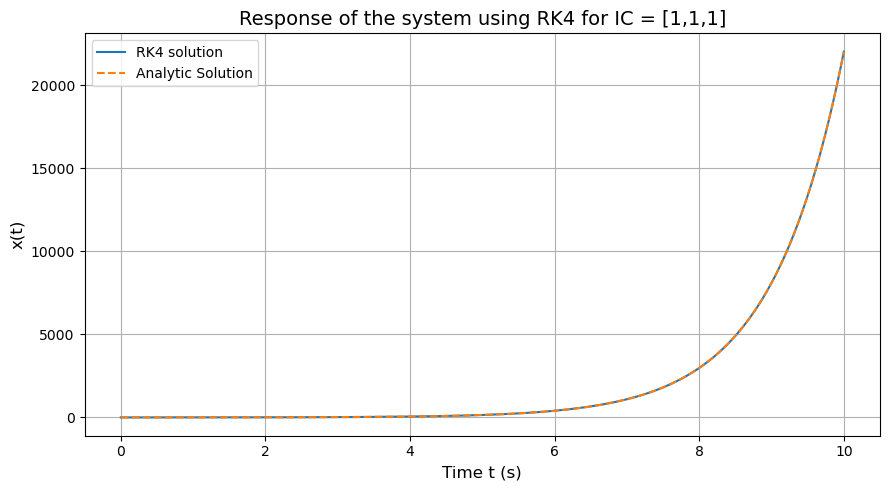

In [4]:
# Plot results
plt.figure(figsize=(9,5))
plt.plot(t_vals, Y1[:,0], label='RK4 solution')
plt.plot(t_vals, np.exp(t_vals), '--', label='Analytic Solution')
plt.xlabel('Time t (s)', fontsize=12)
plt.ylabel('x(t)', fontsize=12)
plt.title('Response of the system using RK4 for IC = [1,1,1]', fontsize=14)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

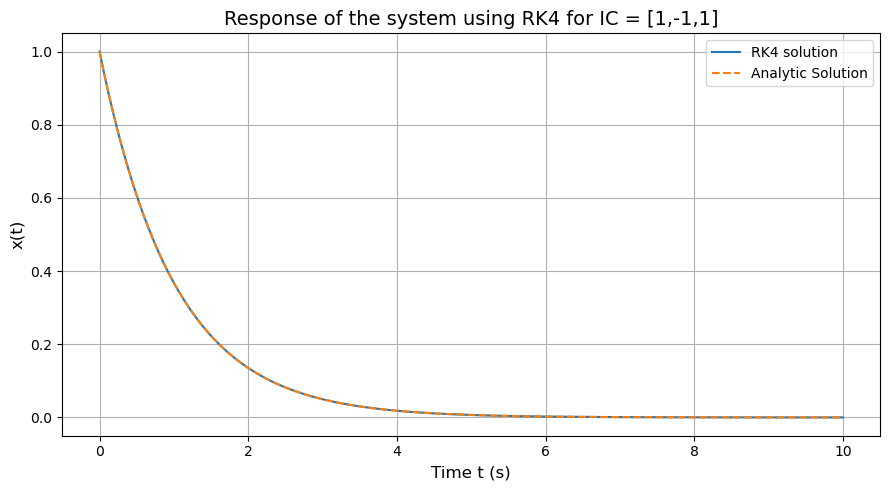

In [5]:
plt.figure(figsize=(9,5))
plt.plot(t_vals, Y2[:,0], label='RK4 solution')
plt.plot(t_vals, np.exp(-t_vals), '--', label='Analytic Solution')
plt.xlabel('Time t (s)', fontsize=12)
plt.ylabel('x(t)', fontsize=12)
plt.title('Response of the system using RK4 for IC = [1,-1,1]', fontsize=14)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

The Analytic and Numerical Solutions agree.

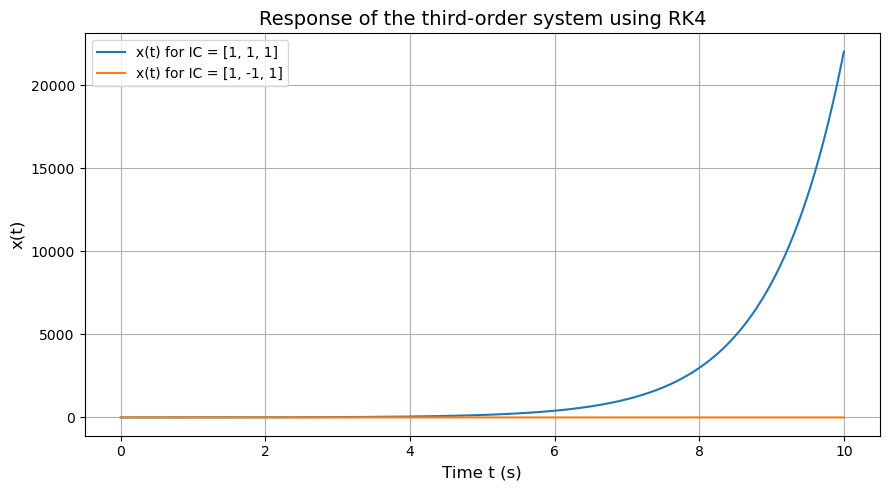

In [6]:
plt.figure(figsize=(9,5))
plt.plot(t_vals, Y1[:,0], label='x(t) for IC = [1, 1, 1]')
plt.plot(t_vals, Y2[:,0], label='x(t) for IC = [1, -1, 1]')
plt.xlabel('Time t (s)', fontsize=12)
plt.ylabel('x(t)', fontsize=12)
plt.title('Response of the third-order system using RK4', fontsize=14)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Question 4d

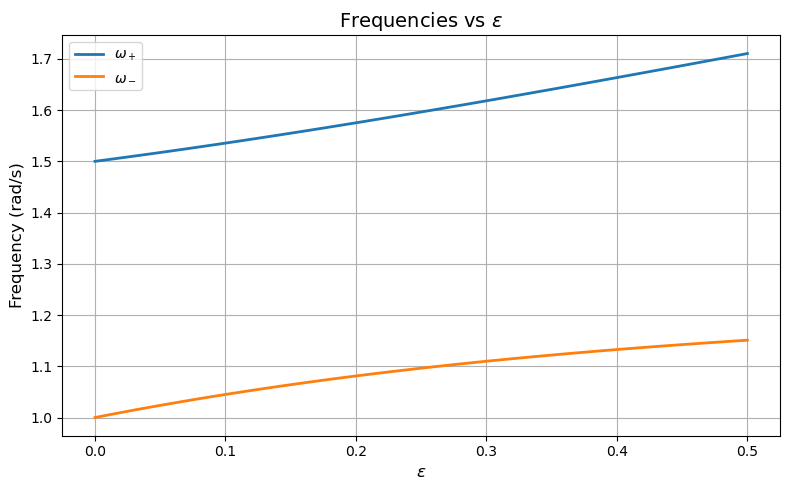

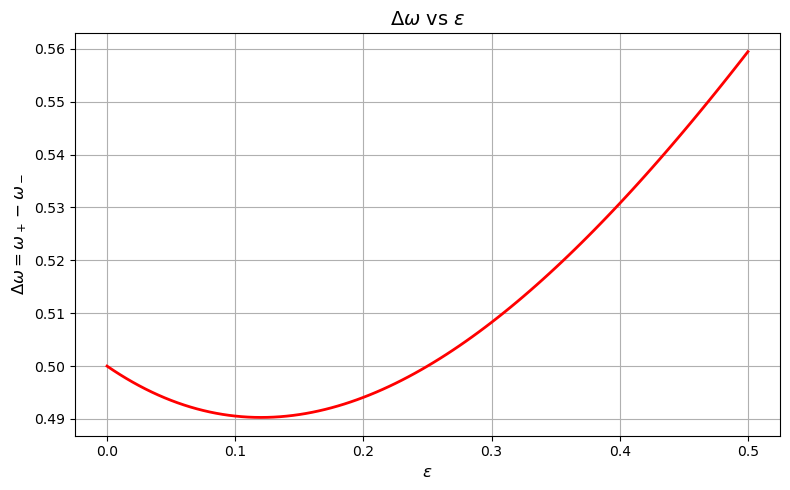

In [9]:

# Parameters
w1 = 1.0       # Natural frequency of first oscillator
w2 = 1.5       # Natural frequency of second oscillator
E = np.arange(0, 0.5 + 0.005, 0.005)   # Range of ε

# Arrays to store the two mode frequencies at each ε
pos_freq = []   # Higher (ω+)
neg_freq = []   # Lower (ω−)

# Loop over ε values and compute eigenvalues of the system
for eps in E:
    # State-space matrix A for coupled oscillators
    # State vector: x = [θ1, θ2, θ̇1, θ̇2]^T
    A = np.array([
        [0, 0, 1, 0],
        [0, 0, 0, 1],
        [-(w1**2 + eps),  eps,  0, 0],
        [ eps, -(w2**2 + eps), 0, 0]
    ])
    
    # Compute eigenvalues of A
    eigvals = np.linalg.eigvals(A)
    
    # Extract imaginary parts only (system is conservative means purely imaginary eigenvalues)
    # Each conjugate pair corresponds to ±jω so taking positive imaginary parts as ω values
    omegas = np.sort(np.abs(np.imag(eigvals[eigvals.imag > 0])))
    
    pos_freq.append(omegas[1])
    neg_freq.append(omegas[0])

pos_freq = np.array(pos_freq)
neg_freq = np.array(neg_freq)

# Plot the two frequencies as a function of ε
plt.figure(figsize=(8,5))
plt.plot(E, pos_freq, label=r'$\omega_+$', linewidth=2)
plt.plot(E, neg_freq, label=r'$\omega_-$', linewidth=2)
plt.xlabel(r'$\epsilon$', fontsize=12)
plt.ylabel('Frequency (rad/s)', fontsize=12)
plt.title('Frequencies vs '  r'$\epsilon$', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot the difference of the two frequencies as a function of ε
plt.figure(figsize=(8,5))
plt.plot(E, pos_freq - neg_freq, 'r', linewidth=2)
plt.xlabel(r'$\epsilon$', fontsize=12)
plt.ylabel(r'$\Delta \omega = \omega_+ - \omega_-$', fontsize=12)
plt.title(r'$\Delta\omega$' ' vs ' r'$\epsilon$', fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()


Question 4f

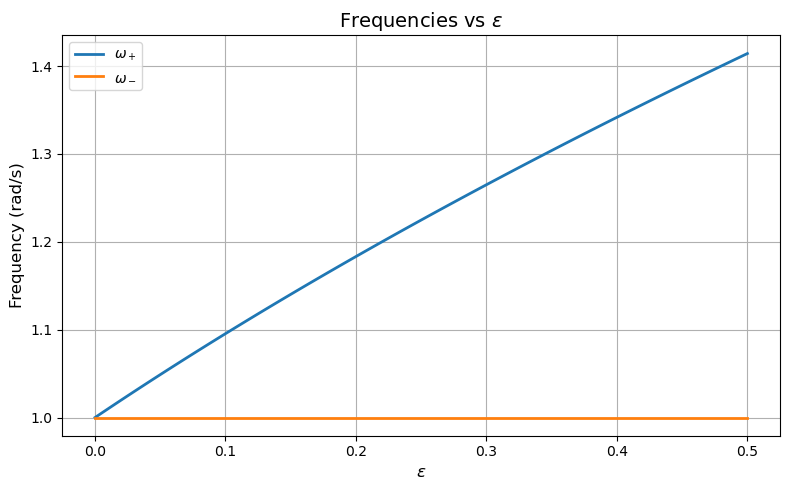

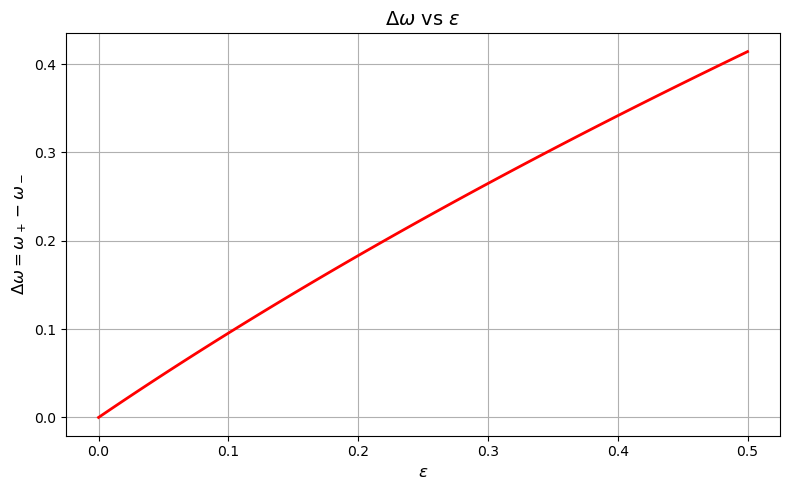

In [8]:

# Parameters
w1 = 1.0       # Natural frequency of first oscillator
w2 = 1.0       # Natural frequency of second oscillator (taken same)
E = np.arange(0, 0.5 + 0.005, 0.005)   # Range of ε

# Arrays to store the two mode frequencies at each ε
pos_freq = []   # Higher (ω+)
neg_freq = []   # Lower (ω−)

# Loop over ε values and compute eigenvalues of the system
for eps in E:
    # State-space matrix A for coupled oscillators
    # State vector: x = [θ1, θ2, θ̇1, θ̇2]^T
    A = np.array([
        [0, 0, 1, 0],
        [0, 0, 0, 1],
        [-(w1**2 + eps),  eps,  0, 0],
        [ eps, -(w2**2 + eps), 0, 0]
    ])
    
    # Compute eigenvalues of A
    eigvals = np.linalg.eigvals(A)
    
    # Extract imaginary parts only (system is conservative means purely imaginary eigenvalues)
    # Each conjugate pair corresponds to ±jω so taking positive imaginary parts as ω values
    omegas = np.sort(np.abs(np.imag(eigvals[eigvals.imag > 0])))
    
    pos_freq.append(omegas[1])
    neg_freq.append(omegas[0])

pos_freq = np.array(pos_freq)
neg_freq = np.array(neg_freq)

# Plot the two frequencies as a function of ε
plt.figure(figsize=(8,5))
plt.plot(E, pos_freq, label=r'$\omega_+$', linewidth=2)
plt.plot(E, neg_freq, label=r'$\omega_-$', linewidth=2)
plt.xlabel(r'$\epsilon$', fontsize=12)
plt.ylabel('Frequency (rad/s)', fontsize=12)
plt.title('Frequencies vs ' r'$\epsilon$', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot the difference of the two frequencies as a function of ε
plt.figure(figsize=(8,5))
plt.plot(E, pos_freq - neg_freq, 'r', linewidth=2)
plt.xlabel(r'$\epsilon$', fontsize=12)
plt.ylabel(r'$\Delta \omega = \omega_+ - \omega_-$', fontsize=12)
plt.title(r'$\Delta\omega$' ' vs ' r'$\epsilon$', fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()
